In [1]:
!pip install pandas matplotlib tqdm numpy ipywidgets dnspython

In [2]:
import subprocess, pandas as pd, matplotlib.pyplot as plt, re, statistics, numpy as np
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import shutil, sys, platform, time, argparse, json

if 'ipykernel' in sys.modules:
    get_ipython().run_line_magic('matplotlib', 'inline')

DEFAULT_DNS_SERVERS ={
    "Google IPv4": "8.8.8.8",
    "Google IPv6": "2001:4860:4860::8888",
    "Cloudflare IPv4": "1.1.1.1",
    "Cloudflare IPv6": "2606:4700:4700::1111",
    "Quad9 IPv4": "9.9.9.9",
    "Quad9 IPv6": "2620:fe::fe",
    "Quad9 edns IPv4": "9.9.9.11",
    "Quad9 edns IPv6": "2620:fe::11",
    "Gcore IPv4": "95.85.95.85",
    "Gcore IPv6": "2a03:90c0:999d::1",
    "OpenDNS IPv4": "208.67.222.222",
    "OpenDNS IPv6": "2620:119:35::35"
} 
DEFAULT_DOMAINS = [
    # 🌐 Popular websites
    "google.com", "youtube.com", "facebook.com", "amazon.com",
    "wikipedia.org", "apple.com", "microsoft.com", "instagram.com",
    "linkedin.com", "bing.com", "reddit.com", "netflix.com",
    "spotify.com", "quora.com", "twitch.tv", "zoom.us",
    "nytimes.com", "bbc.com", "espn.com", "whatsapp.com",
    "twitter.com", "tiktok.com", "pinterest.com", "ebay.com",
    "imdb.com", "cnn.com", "paypal.com", "booking.com",
    "weather.com", "wordpress.com", "airbnb.com", "tumblr.com",

    # 👨‍💻 Developer platforms & registries
    "github.com", "gitlab.com", "stackoverflow.com", "docker.com",
    "pypi.org", "files.pythonhosted.org", "npmjs.com", "registry.npmjs.org",
    "rubygems.org", "repo.maven.apache.org", "cran.r-project.org",
    "bitbucket.org", "sourceforge.net", "dev.to", "jetbrains.com",
    "readthedocs.io", "godoc.org", "anaconda.org", "registry.terraform.io",
    "grafana.com", "prometheus.io", "circleci.com", "travis-ci.com",

    # 🌩️ CDN / DNS / infrastructure
    "cloudflare.com", "cdn.cloudflare.net", "one.one.one.one", "dns.google",
    "cloudfront.net", "fastly.net", "akamai.net", "edgesuite.net",
    "opendns.com", "quad9.net", "adguard.com", "nextdns.io",
    "cleanbrowsing.org", "verisign.com", "resolver.arpa",
    "ultradns.com", "nsone.net", "level3.com", "resolv.conf",
    "akamaihd.net", "akamai.com", "edgekey.net", "dns.adguard-dns.com",
    "cachefly.net", "stackpathdns.com", "zenedge.net", "he.net",

    # 🌍 Regional domains
    "baidu.com", "yandex.ru", "naver.com", "jio.com",
    "nic.in", "gov.uk", "zone.ug", "nic.coop", "cern.ch",
    "nic.cl", "nic.br", "nic.cn", "nic.ru", "nic.af", "nic.ng",
    "sina.com.cn", "mail.ru", "globo.com", "sapo.pt", "or.kr",
    "nic.or.kr", "telstra.com.au", "rogers.com", "ntt.com",
    "bell.ca", "kpn.com", "proximus.be",

    # 🧪 Rare / test / diagnostics
    "example.net", "example.edu", "iana.org", "blackhole.webpagetest.org",
    "test-ipv6.com", "test.openresolver.com", "whoami.akamai.net",
    "myip.opendns.com", "root-servers.net", "ip6.nl", "openstreetmap.fr",
    "torproject.org", "xip.io", "plan99.net", "dnscrypt.info", "dnspython.org",
    "publicsuffix.org", "openwrt.org", "nlnetlabs.nl", "labnbook.com",
    "archive.org", "dl.acm.org", "nvlpubs.nist.gov", "eprints.soton.ac.uk",
    "rsdn.org", "dnscheck.tools", "dnsleaktest.com", "checkmydns.net",
    "ipinfo.io", "whatismyip.akamai.com", "trace.test", "cloudping.info",
    "speed.cloudflare.com", "bgp.he.net", "ping.pe", "ping.eu",

    # 🛰️ Root / TLD / Authority related
    "root-servers.org", "a.root-servers.net", "l.root-servers.net",
    "iana.com", "int", "arpa", "whois.iana.org", "tld-list.com"
]

TRIES, MAX_RETRIES, TIMEOUT = 5, 2, 3

def check_dig_installed():
    if shutil.which("dig") is None:
        print("❌ 'dig' command not found. Please install it.")
        sys.exit(1)

def test_connectivity(ip):
    param = "-n" if platform.system().lower() == "windows" else "-c"
    timeout_param = "-w" if platform.system().lower() == "windows" else "-W"
    try:
        result = subprocess.run(
            ["ping", param, "1", timeout_param, "1", ip],
            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
        )
        return result.returncode == 0
    except:
        return False

def filter_reachable_dns_servers(dns_servers):
    def check(label_ip):
        label, ip = label_ip
        if ":" in ip and not test_connectivity(ip):
            print(f"⚠️ Skipping unreachable IPv6 DNS: {label} ({ip})")
            return None
        return (label, ip)

    with ThreadPoolExecutor() as executor:
        results = list(executor.map(check, dns_servers.items()))
    return {label: ip for label, ip in results if label}

def run_dig_command(cmd):
    try:
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=TIMEOUT)
        return result.stdout
    except subprocess.TimeoutExpired:
        return None
    except Exception as e:
        return str(e)

def parse_dig_output(output):
    if not output:
        return None
    match = re.search(r"Query time:\s*(\d+)\s*msec", output)
    return int(match.group(1)) if match else None

def query_dns_single(args):
    dns_label, dns_ip, domain = args
    times = []
    for i in range(TRIES):
        cmd = ["dig", f"@{dns_ip}", domain, "+stats", "+nocomments", "+time=2"]
        backoff = 1
        for attempt in range(MAX_RETRIES + 1):
            output = run_dig_command(cmd)
            time_ms = parse_dig_output(output)
            if time_ms is not None:
                times.append(time_ms)
                break
            time.sleep(backoff)
            backoff *= 2
    if times:
        return {
            "DNS": dns_label, "Domain": domain,
            "AvgTime": sum(times)/len(times), "MedianTime": statistics.median(times),
            "MinTime": min(times), "MaxTime": max(times),
            "StdDev": statistics.stdev(times) if len(times) > 1 else 0.0,
            "ValidTries": len(times), "FailedTries": TRIES - len(times)
        }
    else:
        return {
            "DNS": dns_label, "Domain": domain,
            "AvgTime": None, "MedianTime": None,
            "MinTime": None, "MaxTime": None,
            "StdDev": None, "ValidTries": 0, "FailedTries": TRIES
        }

def plot_per_domain(df):
    for domain in df["Domain"].unique():
        df_domain = df[df["Domain"] == domain]
        ipv4 = df_domain[df_domain["DNS"].str.contains("IPv4")]
        ipv6 = df_domain[df_domain["DNS"].str.contains("IPv6")]
        x_ipv4, x_ipv6 = np.arange(len(ipv4)), np.arange(len(ipv6)) + 0.4
        plt.figure(figsize=(10, 5))
        plt.bar(x_ipv4, ipv4["AvgTime"], width=0.35, label="IPv4")
        plt.bar(x_ipv6, ipv6["AvgTime"], width=0.35, label="IPv6")
        xticks = list(ipv4["DNS"]) + list(ipv6["DNS"])
        xtick_pos = list(x_ipv4) + list(x_ipv6)
        plt.xticks(xtick_pos, xticks, rotation=45, ha="right")
        plt.ylabel("Avg Time (ms)"); plt.title(f"{domain} Resolution Time")
        plt.grid(True, linestyle="--", alpha=0.5); plt.legend(); plt.tight_layout(); plt.show()

def plot_overall_latency(df):
    avg = df[df["AvgTime"].notnull()].groupby("DNS")["AvgTime"].mean().sort_values()
    plt.figure(figsize=(12, 5)); avg.plot(kind="bar", color="skyblue")
    plt.title("Overall Average DNS Latency"); plt.ylabel("Avg Time (ms)")
    plt.xticks(rotation=45, ha="right"); plt.grid(True, linestyle="--", alpha=0.5); plt.tight_layout(); plt.show()

def load_config(config_file):
    try:
        with open(config_file, "r") as f:
            cfg = json.load(f)
        return cfg.get("dns_servers", {}), cfg.get("domains", [])
    except:
        return {}, []

def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument("--config", default="config.json", help="JSON config")
    return parser.parse_args([]) if 'ipykernel' in sys.modules else parser.parse_args()

def main():
    args = parse_args()
    cfg_dns, cfg_domains = load_config(args.config)
    dns_servers = cfg_dns or DEFAULT_DNS_SERVERS
    domains = cfg_domains or DEFAULT_DOMAINS

    check_dig_installed()
    print("🔍 Checking DNS reachability...")
    dns_servers = filter_reachable_dns_servers(dns_servers)
    print(f"✅ Using {len(dns_servers)} DNS servers and {len(domains)} domains.")

    task_list = [(label, ip, domain) for label, ip in dns_servers.items() for domain in domains]
    max_workers = min(32, len(task_list))
    print("🚀 Benchmarking DNS servers...")

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = list(tqdm(executor.map(query_dns_single, task_list), total=len(task_list)))

    df = pd.DataFrame(results)
    df.to_csv("dns_results.csv", index=False)
    print("📁 Results saved to dns_results.csv")

    #plot_per_domain(df)
    plot_overall_latency(df)

    avg_df = df[df["AvgTime"].notnull()].groupby("DNS")["AvgTime"].mean()
    print("\n🌐 Top 2 IPv4 DNS:")
    print(avg_df[avg_df.index.str.contains("IPv4")].sort_values().head(2))

    print("\n🌐 Top 2 IPv6 DNS:")
    print(avg_df[avg_df.index.str.contains("IPv6")].sort_values().head(2))

if __name__ == "__main__":
    main()


KeyboardInterrupt: 

Running DNS queries for 12 servers and 153 domains...


100%|██████████████████████████████████████████████████████████████████████████████| 1836/1836 [01:03<00:00, 28.78it/s]


Results saved to dns_results_no_dig.csv


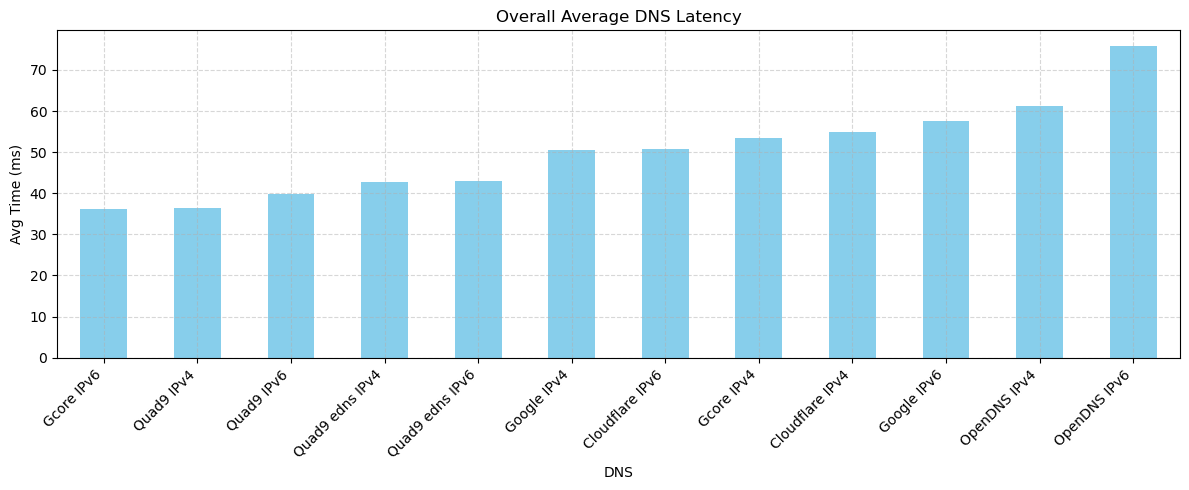


Top 2 IPv4 DNS:
DNS
Quad9 IPv4         36.366899
Quad9 edns IPv4    42.623648
Name: AvgTime, dtype: float64

Top 2 IPv6 DNS:
DNS
Gcore IPv6    36.216166
Quad9 IPv6    39.712807
Name: AvgTime, dtype: float64


In [1]:
import dns.resolver
import pandas as pd
import matplotlib.pyplot as plt
import statistics
import numpy as np
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import json
import argparse
import sys

DEFAULT_DNS_SERVERS ={
    "Google IPv4": "8.8.8.8",
    "Google IPv6": "2001:4860:4860::8888",
    "Cloudflare IPv4": "1.1.1.1",
    "Cloudflare IPv6": "2606:4700:4700::1111",
    "Quad9 IPv4": "9.9.9.9",
    "Quad9 IPv6": "2620:fe::fe",
    "Quad9 edns IPv4": "9.9.9.11",
    "Quad9 edns IPv6": "2620:fe::11",
    "Gcore IPv4": "95.85.95.85",
    "Gcore IPv6": "2a03:90c0:999d::1",
    "OpenDNS IPv4": "208.67.222.222",
    "OpenDNS IPv6": "2620:119:35::35"
} 
DEFAULT_DOMAINS = [
    # 🌐 Popular websites
    "google.com", "youtube.com", "facebook.com", "amazon.com",
    "wikipedia.org", "apple.com", "microsoft.com", "instagram.com",
    "linkedin.com", "bing.com", "reddit.com", "netflix.com",
    "spotify.com", "quora.com", "twitch.tv", "zoom.us",
    "nytimes.com", "bbc.com", "espn.com", "whatsapp.com",
    "twitter.com", "tiktok.com", "pinterest.com", "ebay.com",
    "imdb.com", "cnn.com", "paypal.com", "booking.com",
    "weather.com", "wordpress.com", "airbnb.com", "tumblr.com",

    # 👨‍💻 Developer platforms & registries
    "github.com", "gitlab.com", "stackoverflow.com", "docker.com",
    "pypi.org", "files.pythonhosted.org", "npmjs.com", "registry.npmjs.org",
    "rubygems.org", "repo.maven.apache.org", "cran.r-project.org",
    "bitbucket.org", "sourceforge.net", "dev.to", "jetbrains.com",
    "readthedocs.io", "godoc.org", "anaconda.org", "registry.terraform.io",
    "grafana.com", "prometheus.io", "circleci.com", "travis-ci.com",

    # 🌩️ CDN / DNS / infrastructure
    "cloudflare.com", "cdn.cloudflare.net", "one.one.one.one", "dns.google",
    "cloudfront.net", "fastly.net", "akamai.net", "edgesuite.net",
    "opendns.com", "quad9.net", "adguard.com", "nextdns.io",
    "cleanbrowsing.org", "verisign.com", "resolver.arpa",
    "ultradns.com", "nsone.net", "level3.com", "resolv.conf",
    "akamaihd.net", "akamai.com", "edgekey.net", "dns.adguard-dns.com",
    "cachefly.net", "stackpathdns.com", "zenedge.net", "he.net",

    # 🌍 Regional domains
    "baidu.com", "yandex.ru", "naver.com", "jio.com",
    "nic.in", "gov.uk", "zone.ug", "nic.coop", "cern.ch",
    "nic.cl", "nic.br", "nic.cn", "nic.ru", "nic.af", "nic.ng",
    "sina.com.cn", "mail.ru", "globo.com", "sapo.pt", "or.kr",
    "nic.or.kr", "telstra.com.au", "rogers.com", "ntt.com",
    "bell.ca", "kpn.com", "proximus.be",

    # 🧪 Rare / test / diagnostics
    "example.net", "example.edu", "iana.org", "blackhole.webpagetest.org",
    "test-ipv6.com", "test.openresolver.com", "whoami.akamai.net",
    "myip.opendns.com", "root-servers.net", "ip6.nl", "openstreetmap.fr",
    "torproject.org", "xip.io", "plan99.net", "dnscrypt.info", "dnspython.org",
    "publicsuffix.org", "openwrt.org", "nlnetlabs.nl", "labnbook.com",
    "archive.org", "dl.acm.org", "nvlpubs.nist.gov", "eprints.soton.ac.uk",
    "rsdn.org", "dnscheck.tools", "dnsleaktest.com", "checkmydns.net",
    "ipinfo.io", "whatismyip.akamai.com", "trace.test", "cloudping.info",
    "speed.cloudflare.com", "bgp.he.net", "ping.pe", "ping.eu",

    # 🛰️ Root / TLD / Authority related
    "root-servers.org", "a.root-servers.net", "l.root-servers.net",
    "iana.com", "int", "arpa", "whois.iana.org", "tld-list.com"
]


TRIES = 5
TIMEOUT = 2  # seconds

def query_dns(dns_ip, domain):
    times = []
    resolver = dns.resolver.Resolver(configure=False)
    resolver.nameservers = [dns_ip]
    resolver.timeout = TIMEOUT
    resolver.lifetime = TIMEOUT
    for _ in range(TRIES):
        try:
            import time
            start = time.time()
            answer = resolver.resolve(domain)
            elapsed_ms = (time.time() - start) * 1000
            times.append(elapsed_ms)
        except Exception:
            pass
    return times

def query_dns_single(args):
    dns_label, dns_ip, domain = args
    times = query_dns(dns_ip, domain)
    if times:
        return {
            "DNS": dns_label, "Domain": domain,
            "AvgTime": sum(times) / len(times),
            "MedianTime": statistics.median(times),
            "MinTime": min(times),
            "MaxTime": max(times),
            "StdDev": statistics.stdev(times) if len(times) > 1 else 0.0,
            "ValidTries": len(times),
            "FailedTries": TRIES - len(times),
        }
    else:
        return {
            "DNS": dns_label, "Domain": domain,
            "AvgTime": None,
            "MedianTime": None,
            "MinTime": None,
            "MaxTime": None,
            "StdDev": None,
            "ValidTries": 0,
            "FailedTries": TRIES,
        }

def plot_overall_latency(df):
    avg = df[df["AvgTime"].notnull()].groupby("DNS")["AvgTime"].mean().sort_values()
    plt.figure(figsize=(12, 5))
    avg.plot(kind="bar", color="skyblue")
    plt.title("Overall Average DNS Latency")
    plt.ylabel("Avg Time (ms)")
    plt.xticks(rotation=45, ha="right")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--config", default="config.json", help="JSON config file")
    args = parser.parse_args([]) if 'ipykernel' in sys.modules else parser.parse_args()

    try:
        with open(args.config, "r") as f:
            cfg = json.load(f)
        dns_servers = cfg.get("dns_servers", DEFAULT_DNS_SERVERS)
        domains = cfg.get("domains", DEFAULT_DOMAINS)
    except Exception:
        dns_servers = DEFAULT_DNS_SERVERS
        domains = DEFAULT_DOMAINS

    task_list = [(label, ip, domain) for label, ip in dns_servers.items() for domain in domains]

    max_workers = min(32, len(task_list))
    print(f"Running DNS queries for {len(dns_servers)} servers and {len(domains)} domains...")

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = list(tqdm(executor.map(query_dns_single, task_list), total=len(task_list)))

    df = pd.DataFrame(results)
    df.to_csv("dns_results_no_dig.csv", index=False)
    print("Results saved to dns_results_no_dig.csv")

    plot_overall_latency(df)

    avg_df = df[df["AvgTime"].notnull()].groupby("DNS")["AvgTime"].mean()

    print("\nTop 2 IPv4 DNS:")
    print(avg_df[avg_df.index.str.contains("IPv4")].sort_values().head(2))

    print("\nTop 2 IPv6 DNS:")
    print(avg_df[avg_df.index.str.contains("IPv6")].sort_values().head(2))


if __name__ == "__main__":
    main()
